In [1]:
!pip install -q transformers torch torchvision faiss-cpu sentence-transformers pandas scikit-learn pillow matplotlib streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 53.7 MB/s eta 0:00:00


In [2]:
import os
import json
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from transformers import AutoTokenizer, AutoModel
import torchvision.models as models
import torchvision.transforms as transforms

import faiss

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [4]:
true_df = pd.read_csv("/content/True.csv")
fake_df = pd.read_csv("/content/Fake.csv")

print("True shape:", true_df.shape)
print("Fake shape:", fake_df.shape)

print("\nTrue columns:", true_df.columns.tolist())
print("Fake columns:", fake_df.columns.tolist())

true_df.head()

True shape: (21417, 4)
Fake shape: (23481, 4)

True columns: ['title', 'text', 'subject', 'date']
Fake columns: ['title', 'text', 'subject', 'date']


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [5]:
true_df["label"] = 0   # real
fake_df["label"] = 1   # fake

print(true_df["label"].value_counts())
print(fake_df["label"].value_counts())

label
0    21417
Name: count, dtype: int64
label
1    23481
Name: count, dtype: int64


In [6]:
df = pd.concat([true_df, fake_df], ignore_index=True)

print("Combined shape:", df.shape)
df.head()

Combined shape: (44898, 5)


,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0


In [7]:
df = df[["title", "text", "label"]].copy()

# combine title + text into one stronger input field
df["text"] = df["title"].fillna("") + ". " + df["text"].fillna("")

# keep only final columns
df = df[["text", "label"]]

print(df.shape)
df.head()

(44898, 2)


,text,label
0,"As U.S. budget fight looms, Republicans flip t...",0
1,U.S. military to accept transgender recruits o...,0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,0
3,FBI Russia probe helped by Australian diplomat...,0
4,Trump wants Postal Service to charge 'much mor...,0


In [8]:
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].str.len() > 20].reset_index(drop=True)

print("After cleaning:", df.shape)
print(df["label"].value_counts())

After cleaning: (44898, 2)
label
1    23481
0    21417
Name: count, dtype: int64


In [9]:
df = df.sample(2000, random_state=42).reset_index(drop=True)

print("Working subset shape:", df.shape)
print(df["label"].value_counts())

Working subset shape: (2000, 2)
label
1    1063
0     937
Name: count, dtype: int64


In [10]:
IMAGE_DIR = "/content/images"
os.makedirs(IMAGE_DIR, exist_ok=True)

print("Image folder created:", IMAGE_DIR)

Image folder created: /content/images


In [11]:
import requests
from io import BytesIO

def download_random_image(idx):
    try:
        url = f"https://picsum.photos/224/224?random={idx}"
        response = requests.get(url, timeout=10)
        img = Image.open(BytesIO(response.content)).convert("RGB")

        path = os.path.join(IMAGE_DIR, f"img_{idx}.jpg")
        img.save(path)
        return path
    except Exception as e:
        return None

image_paths = []

In [12]:
for i in range(len(df)):
    path = download_random_image(i)
    image_paths.append(path)

df["image_path"] = image_paths

print(df.head())
print(df["image_path"].isna().sum(), "missing image paths")

                                                text  label  \
0  BREAKING: GOP Chairman Grassley Has Had Enough...      1   
1  Failed GOP Candidates Remembered In Hilarious ...      1   
2  Mike Pence’s New DC Neighbors Are HILARIOUSLY ...      1   
3  California AG pledges to defend birth control ...      0   
4  AZ RANCHERS Living On US-Mexico Border Destroy...      1   

                  image_path  
0  /content/images/img_0.jpg  
1  /content/images/img_1.jpg  
2  /content/images/img_2.jpg  
3  /content/images/img_3.jpg  
4  /content/images/img_4.jpg  
0 missing image paths


In [13]:
df = df.dropna(subset=["image_path"]).reset_index(drop=True)

print("Final dataset shape:", df.shape)
print(df["label"].value_counts())
df.head()

Final dataset shape: (2000, 3)
label
1    1063
0     937
Name: count, dtype: int64


,text,label,image_path
0,BREAKING: GOP Chairman Grassley Has Had Enough...,1,/content/images/img_0.jpg
1,Failed GOP Candidates Remembered In Hilarious ...,1,/content/images/img_1.jpg
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY ...,1,/content/images/img_2.jpg
3,California AG pledges to defend birth control ...,0,/content/images/img_3.jpg
4,AZ RANCHERS Living On US-Mexico Border Destroy...,1,/content/images/img_4.jpg


In [14]:
FINAL_DATASET_PATH = "/content/dataset.csv"
df.to_csv(FINAL_DATASET_PATH, index=False)

print("Saved final dataset to:", FINAL_DATASET_PATH)

Saved final dataset to: /content/dataset.csv


In [15]:
df = pd.read_csv("/content/dataset.csv")
print(df.shape)
print(df.head())
print(df["label"].value_counts())

(2000, 3)
                                                text  label  \
0  BREAKING: GOP Chairman Grassley Has Had Enough...      1   
1  Failed GOP Candidates Remembered In Hilarious ...      1   
2  Mike Pence’s New DC Neighbors Are HILARIOUSLY ...      1   
3  California AG pledges to defend birth control ...      0   
4  AZ RANCHERS Living On US-Mexico Border Destroy...      1   

                  image_path  
0  /content/images/img_0.jpg  
1  /content/images/img_1.jpg  
2  /content/images/img_2.jpg  
3  /content/images/img_3.jpg  
4  /content/images/img_4.jpg  
label
1    1063
0     937
Name: count, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1400, 3)
Val shape: (300, 3)
Test shape: (300, 3)


In [17]:
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
text_encoder = AutoModel.from_pretrained("bert-base-uncased").to(device)
text_encoder.eval()

print("BERT loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded


In [18]:
import torchvision.models as models
import torch.nn as nn

weights = models.ResNet50_Weights.DEFAULT
resnet = models.resnet50(weights=weights)

# remove final classification layer
image_encoder = nn.Sequential(*list(resnet.children())[:-1]).to(device)
image_encoder.eval()

print("ResNet-50 loaded")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 83.6MB/s]


ResNet-50 loaded


In [19]:
import torchvision.transforms as transforms

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

print("Image transform ready")

Image transform ready


In [20]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class MultimodalNewsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, text_encoder, image_encoder, image_transform, device):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.text_encoder = text_encoder
        self.image_encoder = image_encoder
        self.image_transform = image_transform
        self.device = device

    def __len__(self):
        return len(self.df)

    def get_text_embedding(self, text):
        inputs = self.tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=256
        )
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = self.text_encoder(**inputs)

        emb = outputs.last_hidden_state[:, 0, :]   # CLS token
        return emb.squeeze(0).cpu()

    def get_image_embedding(self, image_path):
        image = Image.open(image_path).convert("RGB")
        image = self.image_transform(image).unsqueeze(0).to(self.device)

        with torch.no_grad():
            emb = self.image_encoder(image)

        emb = emb.view(emb.size(0), -1)   # [1, 2048]
        return emb.squeeze(0).cpu()

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        text_emb = self.get_text_embedding(row["text"])        # [768]
        image_emb = self.get_image_embedding(row["image_path"]) # [2048]
        label = torch.tensor(row["label"], dtype=torch.long)

        return {
            "text_emb": text_emb,
            "image_emb": image_emb,
            "label": label,
            "text": row["text"],
            "image_path": row["image_path"]
        }

In [21]:
train_dataset = MultimodalNewsDataset(
    train_df, tokenizer, text_encoder, image_encoder, image_transform, device
)

val_dataset = MultimodalNewsDataset(
    val_df, tokenizer, text_encoder, image_encoder, image_transform, device
)

test_dataset = MultimodalNewsDataset(
    test_df, tokenizer, text_encoder, image_encoder, image_transform, device
)

print("Datasets created")
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Datasets created
Train size: 1400
Val size: 300
Test size: 300


In [22]:
def collate_fn(batch):
    text_emb = torch.stack([item["text_emb"] for item in batch])
    image_emb = torch.stack([item["image_emb"] for item in batch])
    labels = torch.stack([item["label"] for item in batch])

    texts = [item["text"] for item in batch]
    image_paths = [item["image_path"] for item in batch]

    return {
        "text_emb": text_emb,
        "image_emb": image_emb,
        "labels": labels,
        "texts": texts,
        "image_paths": image_paths
    }

In [23]:
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print("Dataloaders ready")

Dataloaders ready


In [24]:
batch = next(iter(train_loader))

print("text_emb shape:", batch["text_emb"].shape)
print("image_emb shape:", batch["image_emb"].shape)
print("labels shape:", batch["labels"].shape)

text_emb shape: torch.Size([16, 768])
image_emb shape: torch.Size([16, 2048])
labels shape: torch.Size([16])


In [25]:
class TextOnlyClassifier(nn.Module):
    def __init__(self, text_dim=768, hidden_dim=256, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(text_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, text_emb):
        return self.net(text_emb)

In [26]:
class EarlyFusionClassifier(nn.Module):
    def __init__(self, text_dim=768, image_dim=2048, hidden_dim=256, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(text_dim + image_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, text_emb, image_emb):
        fused = torch.cat([text_emb, image_emb], dim=1)
        return self.net(fused)

In [27]:
class AttentionFusionClassifier(nn.Module):
    def __init__(self, text_dim=768, image_dim=2048, proj_dim=256, num_classes=2):
        super().__init__()

        self.text_proj = nn.Linear(text_dim, proj_dim)
        self.image_proj = nn.Linear(image_dim, proj_dim)

        self.attn_layer = nn.Linear(proj_dim * 2, 2)

        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(proj_dim, num_classes)
        )

    def forward(self, text_emb, image_emb):
        text_h = torch.relu(self.text_proj(text_emb))
        image_h = torch.relu(self.image_proj(image_emb))

        combined = torch.cat([text_h, image_h], dim=1)
        attn_weights = torch.softmax(self.attn_layer(combined), dim=1)

        fused = (
            attn_weights[:, 0:1] * text_h +
            attn_weights[:, 1:2] * image_h
        )

        logits = self.classifier(fused)
        return logits, attn_weights

In [28]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion, model_type="text"):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="Training", leave=False):
        text_emb = batch["text_emb"].to(device)
        image_emb = batch["image_emb"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        if model_type == "text":
            logits = model(text_emb)
        elif model_type == "early":
            logits = model(text_emb, image_emb)
        elif model_type == "attention":
            logits, _ = model(text_emb, image_emb)
        else:
            raise ValueError("Unknown model type")

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().tolist())
        all_labels.extend(labels.detach().cpu().tolist())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="binary", zero_division=0
    )

    return total_loss / len(loader), acc, precision, recall, f1

In [29]:
def evaluate_model(model, loader, criterion, model_type="text"):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []
    all_attn = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            text_emb = batch["text_emb"].to(device)
            image_emb = batch["image_emb"].to(device)
            labels = batch["labels"].to(device)

            if model_type == "text":
                logits = model(text_emb)
            elif model_type == "early":
                logits = model(text_emb, image_emb)
            elif model_type == "attention":
                logits, attn = model(text_emb, image_emb)
                all_attn.extend(attn.cpu().tolist())
            else:
                raise ValueError("Unknown model type")

            loss = criterion(logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="binary", zero_division=0
    )

    return {
        "loss": total_loss / len(loader),
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "preds": all_preds,
        "labels": all_labels,
        "attn_weights": all_attn
    }

In [30]:
def train_model(model, train_loader, val_loader, model_type="text", epochs=3, lr=1e-3):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, model_type=model_type)
        val_metrics = evaluate_model(model, val_loader, criterion, model_type=model_type)

        print(
            f"Train Loss={train_metrics[0]:.4f}, "
            f"Train Acc={train_metrics[1]:.4f}, "
            f"Train F1={train_metrics[4]:.4f}"
        )
        print(
            f"Val Loss={val_metrics['loss']:.4f}, "
            f"Val Acc={val_metrics['accuracy']:.4f}, "
            f"Val F1={val_metrics['f1']:.4f}"
        )

    return model

In [31]:
text_model = TextOnlyClassifier()
text_model = train_model(
    text_model,
    train_loader,
    val_loader,
    model_type="text",
    epochs=3,
    lr=1e-3
)


Epoch 1/3


Train Loss=0.2296, Train Acc=0.9029, Train F1=0.9104
Val Loss=0.2864, Val Acc=0.8767, Val F1=0.8693

Epoch 2/3


Train Loss=0.1222, Train Acc=0.9557, Train F1=0.9582
Val Loss=0.0952, Val Acc=0.9600, Val F1=0.9618

Epoch 3/3


Train Loss=0.0869, Train Acc=0.9700, Train F1=0.9718
Val Loss=0.0895, Val Acc=0.9567, Val F1=0.9579


In [32]:
early_model = EarlyFusionClassifier()
early_model = train_model(
    early_model,
    train_loader,
    val_loader,
    model_type="early",
    epochs=3,
    lr=1e-3
)


Epoch 1/3


Train Loss=0.2380, Train Acc=0.9043, Train F1=0.9096
Val Loss=0.1525, Val Acc=0.9333, Val F1=0.9390

Epoch 2/3


Train Loss=0.1142, Train Acc=0.9536, Train F1=0.9566
Val Loss=0.1561, Val Acc=0.9333, Val F1=0.9355

Epoch 3/3


Train Loss=0.0715, Train Acc=0.9757, Train F1=0.9771
Val Loss=0.1883, Val Acc=0.9333, Val F1=0.9342


In [33]:
attention_model = AttentionFusionClassifier()
attention_model = train_model(
    attention_model,
    train_loader,
    val_loader,
    model_type="attention",
    epochs=3,
    lr=1e-3
)


Epoch 1/3


Train Loss=0.2093, Train Acc=0.9129, Train F1=0.9177
Val Loss=0.1420, Val Acc=0.9433, Val F1=0.9489

Epoch 2/3


Train Loss=0.1287, Train Acc=0.9557, Train F1=0.9583
Val Loss=0.0887, Val Acc=0.9633, Val F1=0.9651

Epoch 3/3


Train Loss=0.0972, Train Acc=0.9571, Train F1=0.9596
Val Loss=0.1418, Val Acc=0.9400, Val F1=0.9464


In [34]:
criterion = nn.CrossEntropyLoss()

text_test = evaluate_model(text_model, test_loader, criterion, model_type="text")
early_test = evaluate_model(early_model, test_loader, criterion, model_type="early")
attention_test = evaluate_model(attention_model, test_loader, criterion, model_type="attention")

print("Text-only test:", text_test)
print("Early-fusion test:", early_test)
print("Attention-fusion test:", attention_test)

Text-only test: {'loss': 0.09210237127875812, 'accuracy': 0.96, 'precision': 0.9932885906040269, 'recall': 0.9308176100628931, 'f1': 0.961038961038961, 'preds': [1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0

In [35]:
results_df = pd.DataFrame([
    {
        "model": "Text Only",
        "accuracy": text_test["accuracy"],
        "precision": text_test["precision"],
        "recall": text_test["recall"],
        "f1": text_test["f1"]
    },
    {
        "model": "Early Fusion",
        "accuracy": early_test["accuracy"],
        "precision": early_test["precision"],
        "recall": early_test["recall"],
        "f1": early_test["f1"]
    },
    {
        "model": "Attention Fusion",
        "accuracy": attention_test["accuracy"],
        "precision": attention_test["precision"],
        "recall": attention_test["recall"],
        "f1": attention_test["f1"]
    }
])

results_df

,model,accuracy,precision,recall,f1
0,Text Only,0.960000,0.993289,0.930818,0.961039
1,Early Fusion,0.943333,0.993056,0.899371,0.943894
2,Attention Fusion,0.943333,0.903409,1.000000,0.949254


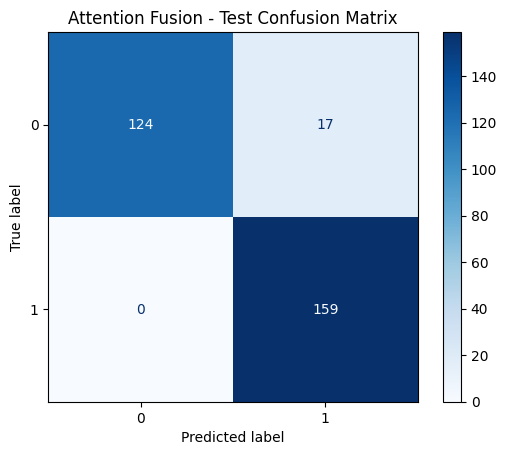

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(attention_test["labels"], attention_test["preds"])

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Attention Fusion - Test Confusion Matrix")
plt.show()

In [37]:
import numpy as np

attn = np.array(attention_test["attn_weights"])
print("Average text attention:", attn[:, 0].mean())
print("Average image attention:", attn[:, 1].mean())

Average text attention: 0.9994159251451492
Average image attention: 0.0005840706312142648


In [38]:
def get_attention_embeddings(model, loader):
    model.eval()
    embedding_list = []
    meta = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Building embeddings", leave=False):
            text_emb = batch["text_emb"].to(device)
            image_emb = batch["image_emb"].to(device)

            text_h = torch.relu(model.text_proj(text_emb))
            image_h = torch.relu(model.image_proj(image_emb))

            combined = torch.cat([text_h, image_h], dim=1)
            attn_weights = torch.softmax(model.attn_layer(combined), dim=1)

            fused = (
                attn_weights[:, 0:1] * text_h +
                attn_weights[:, 1:2] * image_h
            )

            embedding_list.append(fused.cpu().numpy())

            for t, p in zip(batch["texts"], batch["image_paths"]):
                meta.append({
                    "text": t,
                    "image_path": p
                })

    embeddings = np.vstack(embedding_list).astype("float32")
    return embeddings, meta

In [39]:
train_embeddings, train_meta = get_attention_embeddings(attention_model, train_loader)

dimension = train_embeddings.shape[1]
faiss_index = faiss.IndexFlatL2(dimension)
faiss_index.add(train_embeddings)

print("Embedding shape:", train_embeddings.shape)
print("FAISS index size:", faiss_index.ntotal)

Embedding shape: (1400, 256)
FAISS index size: 1400


In [40]:
def search_similar_examples(query_embedding, index, metadata, top_k=3):
    distances, indices = index.search(
        query_embedding.reshape(1, -1).astype("float32"),
        top_k
    )

    results = []
    for dist, idx in zip(distances[0], indices[0]):
        results.append({
            "distance": float(dist),
            "text": metadata[idx]["text"],
            "image_path": metadata[idx]["image_path"]
        })
    return results

QUERY TEXT:
CHICAGO: 117 KILLED, 572 SHOT In 71 Days…Obama Terrorist Friend, Bill Ayers, Bernie Sanders, Black Lives Matter Make Violence Against FREE SPEECH Top Priority… Soros Group Openly Threatens Americans. Illegal aliens, paid Soros protesters, angry Black Lives Matter terrorists inspired by Obama s race war and Bernie Sanders supporters who have absolutely no idea why they showed up, sent four innocent police officers to the hospital; prevented thousands of innocent Americans from exercising their Fi


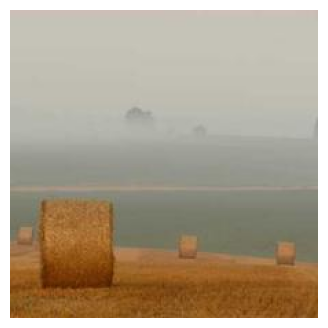


SIMILAR RESULT 1
Distance: 1.9192702770233154
Text: VIOLENT RIOT Shuts Down Free Speech Of Breitbart’s #MiloYiannopoulos #Berkeley [Video]. PRICELESS! MILO DESTROYS Heckling Muslim Woman Crowd Chants USA! USA! USA! [Video] The ironic thing is that a sign had a website on it called:  refuse fascism  We looked into refuse fascism.org and found it s funded by an organization called World Can t Wait (WCW): Founders of WCW included members or supporters of the Revolutionary Communist Party, Greens, anarchists, and people of various other political bac


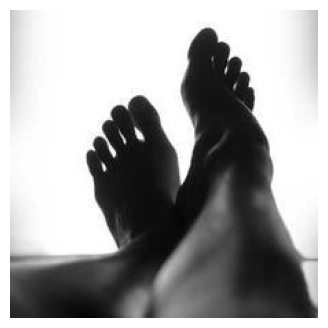


SIMILAR RESULT 2
Distance: 2.4094862937927246
Text: WATCH A SHOCKING VIEW Of A Woman’s Life Under Sharia Law…Women’s March Organizer Is Pro-Sharia Law! [Video]. PLEASE LISTEN TO LINDA SARSOUR SPEAK ABOUT HOW DISSAPOINTED SHE IS THAT 22 STATES HAVE VOTED AGAINST SHARIA LAW:  HAHA! Leader and organizer of Washington #WomensMarch is annoyed that 22 US states don t allow Sharia laws. Blames Islamaphobia! pic.twitter.com/fjN3WQ7p7P  Onlinemagazin (@OnlineMagazin) January 23, 2017 Linda Sarsour, one of the organizers behind Saturday s Women s March, be


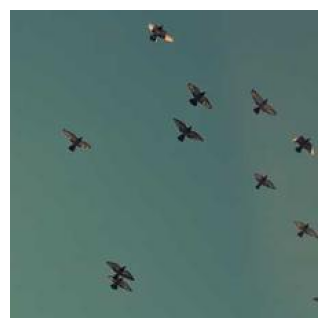


SIMILAR RESULT 3
Distance: 3.087904930114746
Text: BUSTED! CRAIGSLIST AD EXPOSES Rent-a-Mob for Phoenix Anti-Trump Thugs. The usual suspects are going to show up tonight for President Trump s rally in Phoenix, AZ. With Soros and Democrat donors throwing money at rent-a-mobs, you can bet the faux protesters will be out in droves tonight with their mass-produced identical signs. Craigslist had ads for tonight s rally asking for protesters:THE AD WAS FLAGGED:Real post on Craig s list that was flagged and removed asking for professional actors to pr


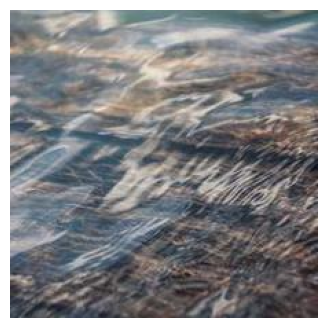

In [44]:
test_embeddings, test_meta = get_attention_embeddings(attention_model, test_loader)

query_idx = 0
query_embedding = test_embeddings[query_idx]

similar_results = search_similar_examples(
    query_embedding,
    faiss_index,
    train_meta,
    top_k=3
)

print("QUERY TEXT:")
print(test_meta[query_idx]["text"][:500])

query_img = Image.open(test_meta[query_idx]["image_path"]).convert("RGB")
plt.figure(figsize=(4, 4))
plt.imshow(query_img)
plt.axis("off")
plt.show()

for i, res in enumerate(similar_results, 1):
    print(f"\nSIMILAR RESULT {i}")
    print("Distance:", res["distance"])
    print("Text:", res["text"][:500])

    sim_img = Image.open(res["image_path"]).convert("RGB")
    plt.figure(figsize=(4, 4))
    plt.imshow(sim_img)
    plt.axis("off")
    plt.show()

In [45]:
MODEL_DIR = "/content/final_saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)

faiss.write_index(faiss_index, os.path.join(MODEL_DIR, "faiss_index.bin"))
np.save(os.path.join(MODEL_DIR, "train_embeddings.npy"), train_embeddings)

with open(os.path.join(MODEL_DIR, "train_meta.json"), "w", encoding="utf-8") as f:
    json.dump(train_meta, f, ensure_ascii=False, indent=2)

torch.save(attention_model.state_dict(), os.path.join(MODEL_DIR, "attention_fusion_model.pt"))

print("Saved everything to:", MODEL_DIR)

Saved everything to: /content/final_saved_models


In [46]:
results_df.to_csv(os.path.join(MODEL_DIR, "results.csv"), index=False)
print(results_df)

              model  accuracy  precision    recall        f1
0         Text Only  0.960000   0.993289  0.930818  0.961039
1      Early Fusion  0.943333   0.993056  0.899371  0.943894
2  Attention Fusion  0.943333   0.903409  1.000000  0.949254
